# Claim Frequency Across the freMTPL2 Portfolio

This notebook explores how observed third-party liability claim frequency varies with driver, vehicle, and geographic characteristics. It uses the policy-level `freMTPL2freq` export from the CASdatasets R package. The [data intake and integrity notebook](01_data_overview.ipynb) documents the source checks.

**Outcome:** `ClaimNb`, the number of claims during a policy's observed exposure. **Denominator:** `Exposure`, measured in years. Group-level frequency is calculated as total claims divided by total exposure, then shown as **claims per 100 exposure-years**. These are descriptive associations; they do not adjust for differences in other policy characteristics.

The analysis below retains the supplied records and keeps `IDpol` as text. This full-portfolio descriptive analysis predates the development/test split introduced in Notebook 04. No frequency model is fitted here.

## 1. Load data and establish the portfolio benchmark

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

frequency = pd.read_csv(
    Path("../data/raw/freMTPL2freq.csv"),
    dtype={"IDpol": "string"},
)

portfolio_policies = len(frequency)
portfolio_exposure = frequency["Exposure"].sum()
portfolio_claims = frequency["ClaimNb"].sum()
portfolio_rate = portfolio_claims / portfolio_exposure * 100

display(pd.DataFrame({
    "policies": [portfolio_policies],
    "exposure_years": [portfolio_exposure],
    "claims": [portfolio_claims],
    "claims_per_100_exposure_years": [portfolio_rate],
}).round(2))

,policies,exposure_years,claims,claims_per_100_exposure_years
0,677991,358482.84,26444,7.38


A portfolio claim rate is a **ratio of totals**: `sum(ClaimNb) / sum(Exposure)`. Averaging each policy's `ClaimNb / Exposure` would give very short exposures too much influence. The rate is a descriptive portfolio measure, not the probability that a policy has at least one claim.

In [11]:
claim_count_distribution = frequency["ClaimNb"].value_counts().sort_index()
display(claim_count_distribution.rename("policy_count").to_frame())

print("Policies with at least one claim:", (frequency["ClaimNb"] > 0).sum())
print("Share of policies with at least one claim:",
      f"{(frequency['ClaimNb'] > 0).mean():.2%}")

,policy_count
ClaimNb,
0,653047
1,23571
2,1298
3,62
4,5
5,2
6,1
8,1
9,1


Policies with at least one claim: 24944
Share of policies with at least one claim: 3.68%


## 2. Compute comparable rates by group

The helper below applies the same denominator and reporting scale to every group. `policies` and `exposure_years` show how much data supports each rate; `relative_to_portfolio` compares the group's observed rate with the portfolio benchmark. Small groups may have unstable rates.

In [12]:
def frequency_by_group(data, group):
    summary = (
        data.groupby(group, observed=True, dropna=False)
        .agg(
            policies=("IDpol", "size"),
            exposure_years=("Exposure", "sum"),
            claims=("ClaimNb", "sum"),
        )
    )
    summary["claims_per_100_exposure_years"] = (
        summary["claims"] / summary["exposure_years"] * 100
    )
    summary["relative_to_portfolio"] = (
        summary["claims_per_100_exposure_years"] / portfolio_rate
    )
    return summary


def plot_group_rate(summary, title, *, rotation=0):
    ax = summary["claims_per_100_exposure_years"].plot.bar(
        figsize=(9, 4), color="#34699a", rot=rotation, legend=False
    )
    reference_line = ax.axhline(
        portfolio_rate, color="#a64b35", linestyle="--", label="Portfolio rate"
    )
    ax.set(title=title, xlabel="", ylabel="Claims per 100 exposure-years")
    ax.legend(handles=[reference_line], frameon=False)
    plt.tight_layout()
    plt.show()

## 3. Driver characteristics

Age and bonus-malus are grouped into broad, readable bands for the first pass. Bands are descriptive choices rather than modeled thresholds. The exposure and claim counts should be considered alongside rate differences.

,policies,exposure_years,claims,claims_per_100_exposure_years,relative_to_portfolio
driver_age_band,,,,,
18–24,30196,12487.37,2011,16.10,2.18
25–34,140944,64597.36,4973,7.70,1.04
35–44,170573,87386.83,6192,7.09,0.96
45–54,164028,89848.00,6802,7.57,1.03
55–64,99091,56174.49,3602,6.41,0.87
65–74,50818,32205.45,1872,5.81,0.79
75+,22341,15783.33,992,6.29,0.85


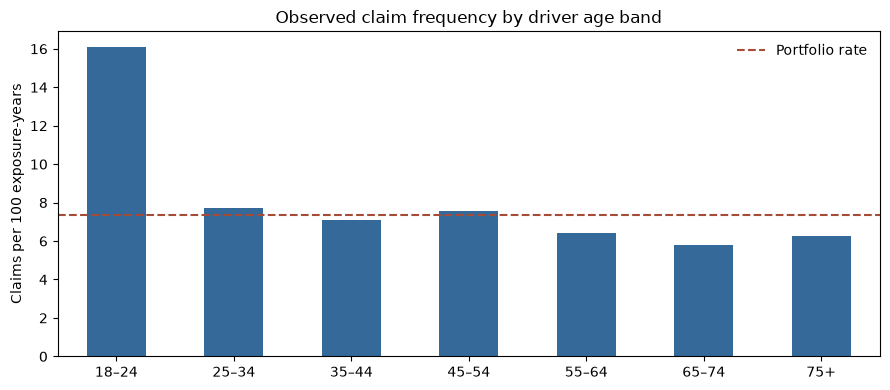

In [13]:
frequency["driver_age_band"] = pd.cut(
    frequency["DrivAge"],
    bins=[18, 25, 35, 45, 55, 65, 75, float("inf")],
    labels=["18–24", "25–34", "35–44", "45–54", "55–64", "65–74", "75+"],
    right=False,
)

driver_age_summary = frequency_by_group(frequency, "driver_age_band")
display(driver_age_summary.round(2))
plot_group_rate(driver_age_summary, "Observed claim frequency by driver age band")

,policies,exposure_years,claims,claims_per_100_exposure_years,relative_to_portfolio
bonus_malus_band,,,,,
<75,557804,309514.35,19283,6.23,0.84
75–99,92863,39156.29,4585,11.71,1.59
100–124,25099,8821.05,2124,24.08,3.26
125+,2225,991.14,452,45.60,6.18


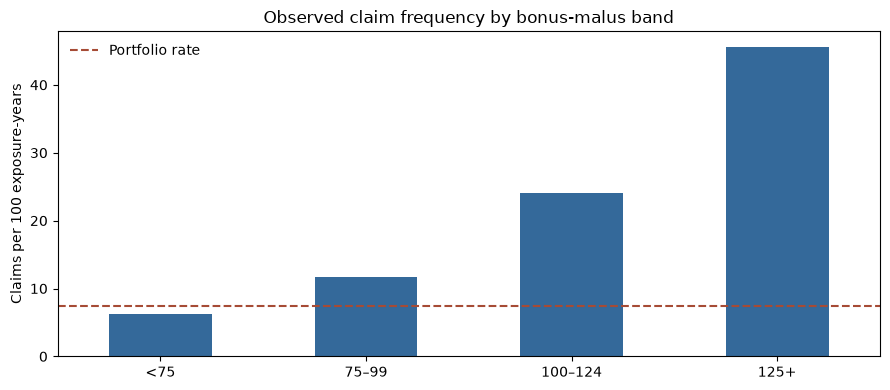

In [14]:
frequency["bonus_malus_band"] = pd.cut(
    frequency["BonusMalus"],
    bins=[0, 75, 100, 125, float("inf")],
    labels=["<75", "75–99", "100–124", "125+"],
    right=False,
)

bonus_malus_summary = frequency_by_group(frequency, "bonus_malus_band")
display(bonus_malus_summary.round(2))
plot_group_rate(bonus_malus_summary, "Observed claim frequency by bonus-malus band")

## 4. Vehicle characteristics

,policies,exposure_years,claims,claims_per_100_exposure_years,relative_to_portfolio
vehicle_age_band,,,,,
0,57739,16719.03,1181,7.06,0.96
1–2,130401,62452.11,4566,7.31,0.99
3–5,132488,72038.12,5344,7.42,1.01
6–10,171587,99003.24,8009,8.09,1.10
11–20,177455,103123.22,7137,6.92,0.94
21+,8321,5147.12,207,4.02,0.55


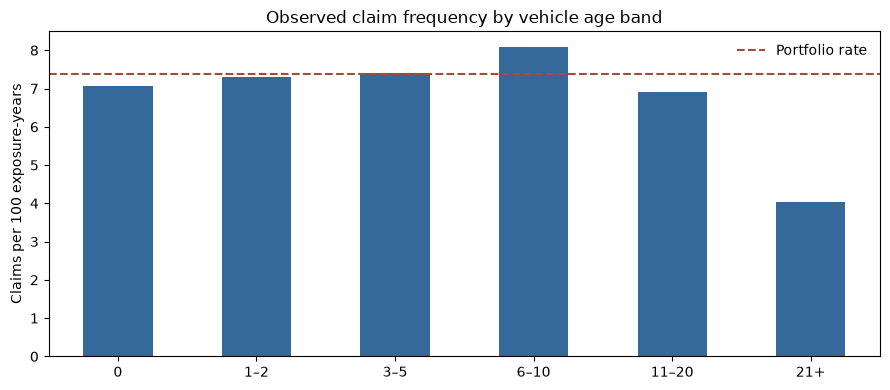

Fuel type


,policies,exposure_years,claims,claims_per_100_exposure_years,relative_to_portfolio
VehGas,,,,,
Diesel,332128,170653.97,13450,7.88,1.07
Regular,345863,187828.86,12994,6.92,0.94


In [15]:
frequency["vehicle_age_band"] = pd.cut(
    frequency["VehAge"],
    bins=[0, 1, 3, 6, 11, 21, float("inf")],
    labels=["0", "1–2", "3–5", "6–10", "11–20", "21+"],
    right=False,
)

vehicle_age_summary = frequency_by_group(frequency, "vehicle_age_band")
display(vehicle_age_summary.round(2))
plot_group_rate(vehicle_age_summary, "Observed claim frequency by vehicle age band")

print("Fuel type")
display(frequency_by_group(frequency, "VehGas").round(2))

In [16]:
print("Vehicle power")
display(frequency_by_group(frequency, "VehPower").round(2))

print("Vehicle brand code")
brand_summary = frequency_by_group(frequency, "VehBrand")
brand_summary = brand_summary.reindex(
    sorted(brand_summary.index, key=lambda brand: int(brand[1:]))
)
display(brand_summary.round(2))

Vehicle power


,policies,exposure_years,claims,claims_per_100_exposure_years,relative_to_portfolio
VehPower,,,,,
4,115344,60069.71,4003,6.66,0.90
5,124815,68168.82,5115,7.50,1.02
6,148972,82520.44,6305,7.64,1.04
7,145398,77948.44,5593,7.18,0.97
8,46954,22682.95,1645,7.25,0.98
9,30084,15348.11,1220,7.95,1.08
10,31353,15374.42,1217,7.92,1.07
11,18352,8497.78,714,8.40,1.14
12,8214,3792.04,296,7.81,1.06


Vehicle brand code


,policies,exposure_years,claims,claims_per_100_exposure_years,relative_to_portfolio
VehBrand,,,,,
B1,162730,95346.55,6898,7.23,0.98
B2,159854,94858.81,6805,7.17,0.97
B3,53393,28591.16,2429,8.50,1.15
B4,25179,13775.50,1099,7.98,1.08
B5,34752,19991.06,1662,8.31,1.13
B6,28545,15682.62,1252,7.98,1.08
B10,17707,9496.01,765,8.06,1.09
B11,13585,6887.82,664,9.64,1.31
B12,166022,64807.40,4200,6.48,0.88


## 5. Geographic characteristics

`Area` is the source's ordered rural-to-urban category. Density groups are quintiles of the **policy rows** and summarize population-density differences without assuming a linear relationship. `Region` is shown separately because regional comparisons may reflect differences in other portfolio characteristics.

,policies,exposure_years,claims,claims_per_100_exposure_years,relative_to_portfolio
Area,,,,,
A,103952,61966.14,3364,5.43,0.74
B,75457,43010.75,2633,6.12,0.83
C,191874,104443.16,7093,6.79,0.92
D,151592,77116.92,6458,8.37,1.14
E,137163,63817.10,6122,9.59,1.30
F,17953,8128.75,774,9.52,1.29


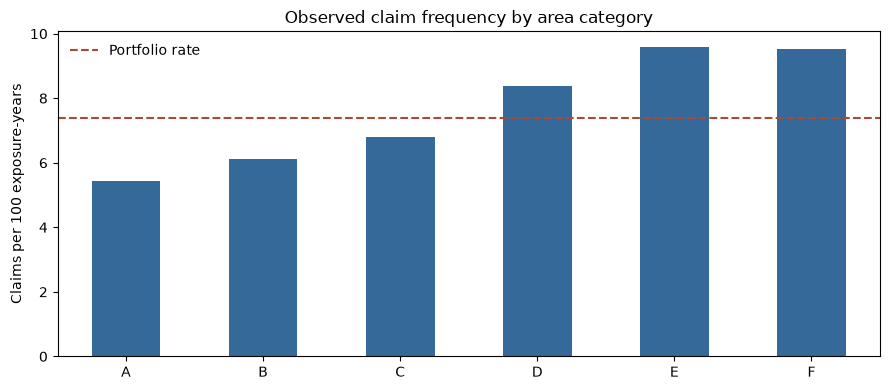

,policies,exposure_years,claims,claims_per_100_exposure_years,relative_to_portfolio
Density (inhabitants/km²),,,,,
1–67,137335,81405.77,4522,5.55,0.75
68–214,134173,74099.81,4839,6.53,0.89
215–716,135393,72036.61,5102,7.08,0.96
"717–2,715",137842,69484.35,6077,8.75,1.19
"2,716–27,000",133248,61456.29,5904,9.61,1.30


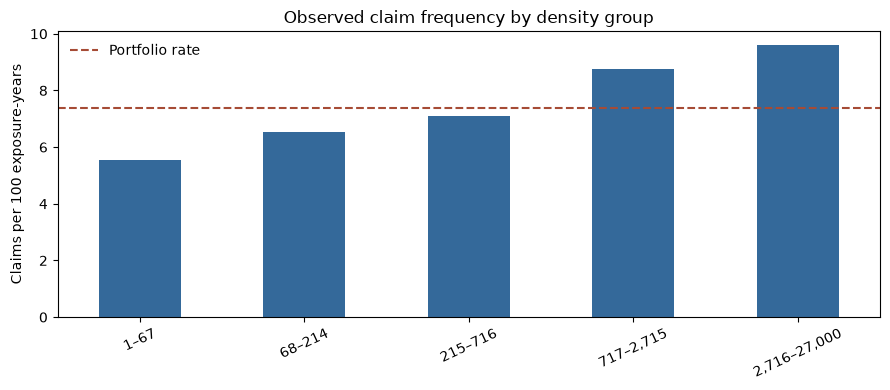

In [17]:
area_summary = frequency_by_group(frequency, "Area").sort_index()
display(area_summary.round(2))
plot_group_rate(area_summary, "Observed claim frequency by area category")

frequency["density_quintile"] = pd.qcut(
    frequency["Density"], q=5, duplicates="drop"
)
density_summary = frequency_by_group(frequency, "density_quintile")
# Relabel the grouped intervals without changing any quintile assignments.
density_summary.index = pd.Index(
    [f"{int(interval.left) + 1:,}–{int(interval.right):,}"
     for interval in density_summary.index],
    name="Density (inhabitants/km²)",
)
display(density_summary.round(2))
plot_group_rate(density_summary, "Observed claim frequency by density group",
                rotation=25)

In [18]:
region_summary = frequency_by_group(frequency, "Region")
display(region_summary.sort_values("exposure_years", ascending=False).round(2))

,policies,exposure_years,claims,claims_per_100_exposure_years,relative_to_portfolio
Region,,,,,
Centre,160595,102707.85,6475,6.30,0.85
Rhone-Alpes,84748,45343.55,4233,9.34,1.27
Provence-Alpes-Cotes-D'Azur,79315,35790.32,2986,8.34,1.13
Ile-de-France,69789,30207.16,2591,8.58,1.16
Bretagne,42120,27752.44,1871,6.74,0.91
Pays-de-la-Loire,38747,21931.15,1576,7.19,0.97
Languedoc-Roussillon,35805,14736.10,1068,7.25,0.98
Aquitaine,31329,14322.17,1055,7.37,1.00
Nord-Pas-de-Calais,27284,11496.97,944,8.21,1.11


## 6. Shape of the main numerical predictors

Broad categories make the first-pass comparisons readable, but they can conceal bends or plateaus. The following views use narrower age and BonusMalus groups and roughly log-spaced density ranges. They are exploratory summaries, **not proposed model cutoffs**. Groups with less than 100 exposure-years remain in their tables but are omitted from the age and density shape plots to avoid visually emphasizing unstable rates.

Individual ages 18–35


,policies,exposure_years,claims,claims_per_100_exposure_years,relative_to_portfolio
DrivAge,,,,,
18,748,210.71,64,30.37,4.12
19,2392,912.89,240,26.29,3.56
20,3676,1460.98,313,21.42,2.90
21,4437,1820.10,314,17.25,2.34
22,5290,2222.86,340,15.30,2.07
23,6260,2671.66,373,13.96,1.89
24,7393,3188.16,367,11.51,1.56
25,8697,3738.74,392,10.48,1.42
26,10301,4456.24,455,10.21,1.38


Ages excluded from plot for <100 exposure-years: 10


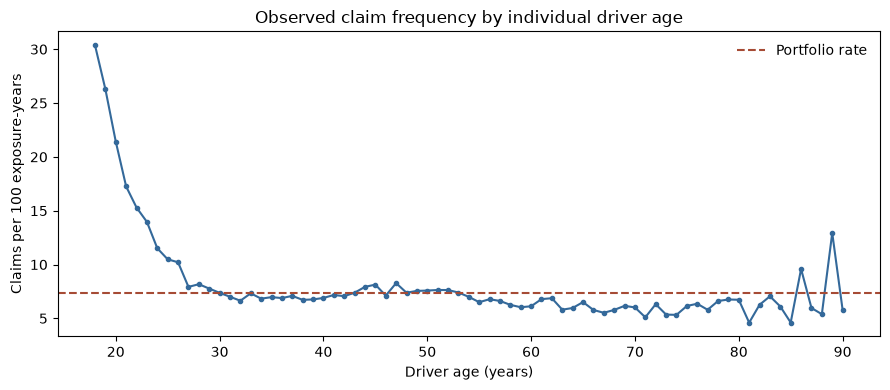

In [19]:
age_detail = frequency_by_group(frequency, "DrivAge").sort_index()
age_supported = age_detail.loc[age_detail["exposure_years"] >= 100]

print("Individual ages 18–35")
display(age_detail.loc[18:35].round(2))
print("Ages excluded from plot for <100 exposure-years:",
      len(age_detail) - len(age_supported))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(age_supported.index, age_supported["claims_per_100_exposure_years"],
        color="#34699a", marker="o", markersize=3)
reference_line = ax.axhline(portfolio_rate, color="#a64b35", linestyle="--",
                            label="Portfolio rate")
ax.set(title="Observed claim frequency by individual driver age",
       xlabel="Driver age (years)", ylabel="Claims per 100 exposure-years")
ax.legend(handles=[reference_line], frameon=False)
plt.tight_layout()
plt.show()

,policies,exposure_years,claims,claims_per_100_exposure_years,relative_to_portfolio
bonus_malus_fine_band,,,,,
50–59,461222,265051.74,14626,5.52,0.75
60–69,73178,34161.01,3580,10.48,1.42
70–79,44852,19642.90,2170,11.05,1.50
80–89,37225,15409.84,1698,11.02,1.49
90–99,34190,14405.15,1794,12.45,1.69
100–109,21489,7146.86,1585,22.18,3.01
110–119,3570,1659.91,534,32.17,4.36
120–129,1480,641.46,296,46.14,6.26
130+,785,363.96,161,44.24,6.00


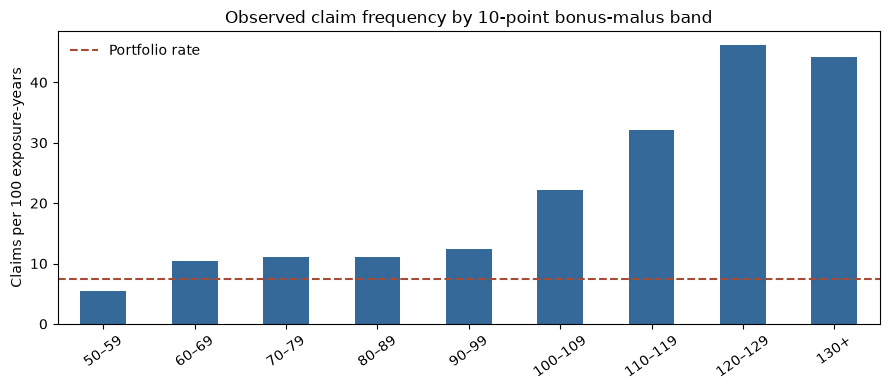

In [20]:
bonus_edges = list(range(50, 131, 10)) + [float("inf")]
bonus_labels = [f"{start}–{start + 9}" for start in range(50, 130, 10)] + ["130+"]
frequency["bonus_malus_fine_band"] = pd.cut(
    frequency["BonusMalus"], bins=bonus_edges, labels=bonus_labels, right=False
)

bonus_fine_summary = frequency_by_group(frequency, "bonus_malus_fine_band")
display(bonus_fine_summary.round(2))
plot_group_rate(bonus_fine_summary,
                "Observed claim frequency by 10-point bonus-malus band",
                rotation=35)

,policies,exposure_years,claims,claims_per_100_exposure_years,relative_to_portfolio,median_density
density_log_band,,,,,,
1–2,99,51.82,3,5.79,0.78,2.0
3–9,5799,3343.87,193,5.77,0.78,8.0
10–29,52360,31943.83,1610,5.04,0.68,19.0
30–99,120713,69423.83,4171,6.01,0.81,57.0
100–299,134361,73678.21,4940,6.70,0.91,176.0
300–999,130525,67807.30,5144,7.59,1.03,548.0
"1,000–2,999",108680,54341.58,4819,8.87,1.20,1466.0
"3,000–9,999",107501,49763.63,4790,9.63,1.30,4116.0
"10,000–30,000",17953,8128.75,774,9.52,1.29,27000.0


Density groups excluded from plot for <100 exposure-years: 1


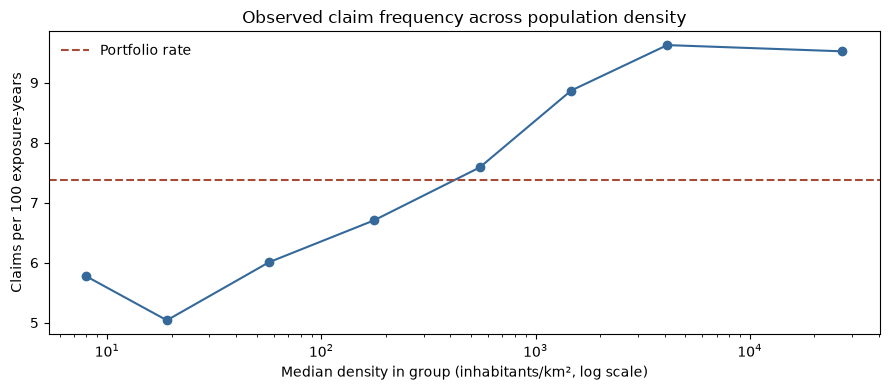

In [21]:
density_edges = [1, 3, 10, 30, 100, 300, 1_000, 3_000, 10_000, 30_001]
density_labels = ["1–2", "3–9", "10–29", "30–99", "100–299",
                  "300–999", "1,000–2,999", "3,000–9,999", "10,000–30,000"]
frequency["density_log_band"] = pd.cut(
    frequency["Density"], bins=density_edges, labels=density_labels, right=False
)

density_shape = frequency_by_group(frequency, "density_log_band")
density_shape["median_density"] = (
    frequency.groupby("density_log_band", observed=True)["Density"].median()
)
display(density_shape.round(2))

density_supported = density_shape.loc[density_shape["exposure_years"] >= 100]
print("Density groups excluded from plot for <100 exposure-years:",
      len(density_shape) - len(density_supported))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(density_supported["median_density"],
        density_supported["claims_per_100_exposure_years"],
        color="#34699a", marker="o")
reference_line = ax.axhline(portfolio_rate, color="#a64b35", linestyle="--",
                            label="Portfolio rate")
ax.set_xscale("log")
ax.set(title="Observed claim frequency across population density",
       xlabel="Median density in group (inhabitants/km², log scale)",
       ylabel="Claims per 100 exposure-years")
ax.legend(handles=[reference_line], frameon=False)
plt.tight_layout()
plt.show()

## 7. Context for the Area comparison

This compact summary checks whether Area tracks population density and whether mean exposure per policy differs across Area groups. It helps interpret the earlier marginal comparisons without attempting a full analysis of predictor relationships.

In [22]:
area_context = (
    frequency.groupby("Area", observed=True)
    .agg(
        policies=("IDpol", "size"),
        mean_exposure_per_policy=("Exposure", "mean"),
        median_density=("Density", "median"),
    )
    .sort_index()
)
display(area_context.round(2))

,policies,mean_exposure_per_policy,median_density
Area,,,
A,103952,0.60,27.0
B,75457,0.57,72.0
C,191874,0.54,222.0
D,151592,0.51,1054.0
E,137163,0.47,3744.0
F,17953,0.45,27000.0


## Descriptive observations

The portfolio baseline is **7.38 claims per 100 exposure-years**. Every comparison below is marginal: it groups policies by one characteristic at a time and does not adjust for differences in the other characteristics.

Drivers aged 18–24 stand out at **16.10** claims per 100 exposure-years, or **2.18×** the portfolio rate. This group has substantial support (about 12,487 exposure-years and 2,011 claims). The individual-age view shows a broad decline through the 20s rather than a single break at age 25; differences among later ages are much smaller. This is an observed association, not evidence of a causal age effect.

**BonusMalus has the clearest descriptive gradient:** frequency rises from **6.23** for values below 75 to **45.60** for values of 125 or more. Finer bands show rates around 10–12 across 60–99 and substantially higher rates above 100, without establishing a modeling cutoff. The highest broad band has far less exposure (about 991 years) than the lower bands, so its rate deserves more caution. BonusMalus also reflects prior claims experience; its association is substantively different from that of an ordinary demographic characteristic.

Vehicle patterns are less pronounced. Diesel policies have **7.88** claims per 100 exposure-years versus **6.92** for Regular fuel. Vehicle-age rates are broadly similar through ages 0–20, while the 21+ group is lower at **4.02** and has relatively little exposure (about 5,147 years). Vehicle power varies modestly and non-monotonically. Brand-code rates differ, but the coded categories alone offer limited substantive interpretation.

Geography shows a clear rural-to-urban gradient: Area increases from **5.43** in A to about **9.5** in E/F, and density quintiles rise monotonically from **5.55** to **9.61**. Finer log-spaced density groups suggest the increase levels off in the densest ranges. Median density rises sharply from Area A to F, so Area and Density capture overlapping information. Mean exposure per policy also falls from about 0.60 years in A to 0.45 in F, illustrating the importance of using claims per exposure-year. Rates vary across regions, but urbanization and other portfolio composition may contribute to those comparisons. These marginal patterns motivated joint examination of the predictors in the initial GLMs (Notebook 04) and the development-stage comparisons that followed (Notebook 05). They remain descriptive findings, not adjusted effects.